before flatten: (60000, 28, 28)
after flatten: (60000, 784)
min pixel value: 0.0
min pixel value: 1.0
sample pixel (raw vs norm): 1 → 0.00392156862745098


C:\Users\Vaishnavi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


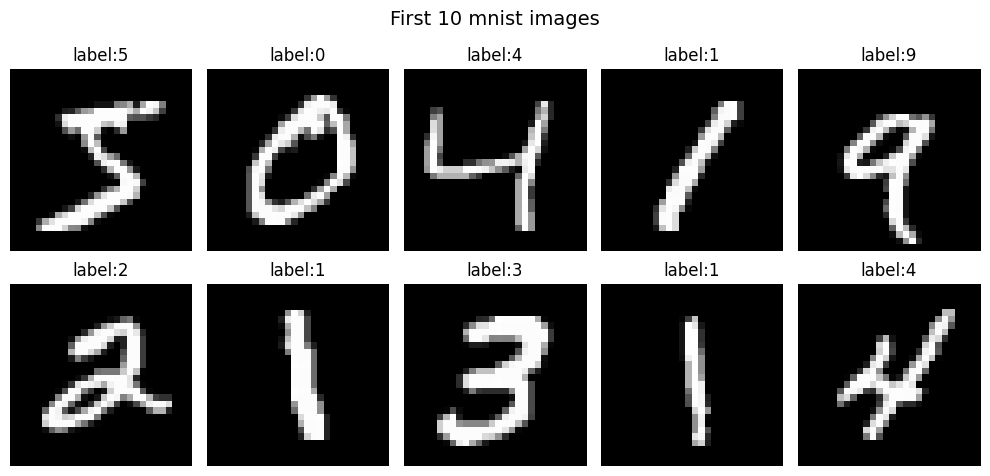

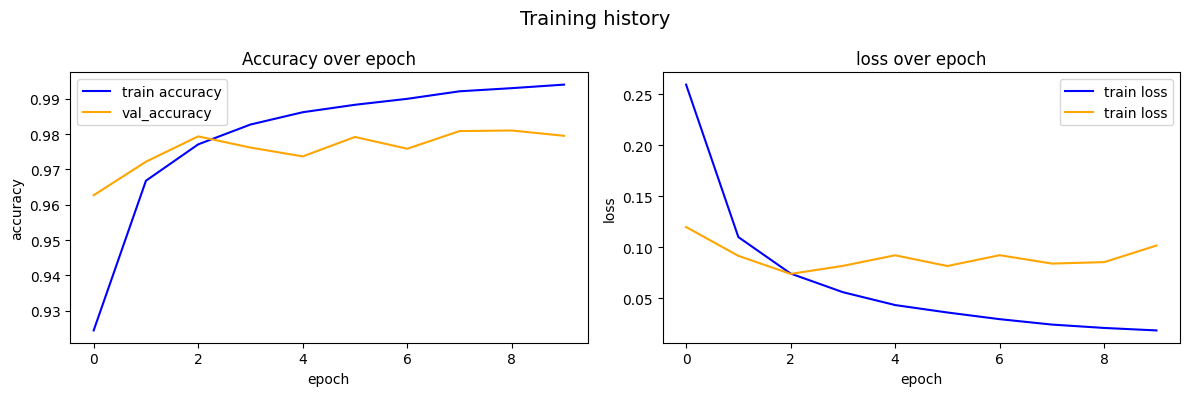

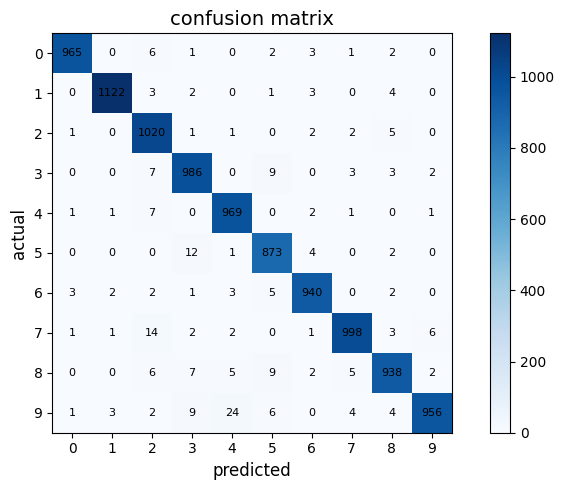

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.99      0.97      1032
           3       0.97      0.98      0.97      1010
           4       0.96      0.99      0.98       982
           5       0.96      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.96      0.97       974
           9       0.99      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



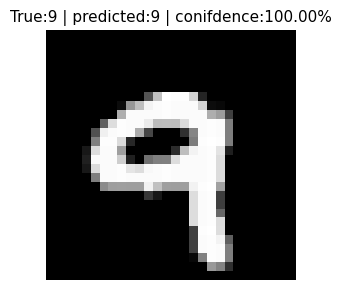

digit0:0.0000 
digit1:0.0000 
digit2:0.0000 
digit3:0.0000 
digit4:0.0000 
digit5:0.0000 
digit6:0.0000 
digit7:0.0000 
digit8:0.0000 
digit9:1.0000 █████████████████████████████████████████████████
model saved sucessfully


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.datasets import mnist

(x_train,y_train),(x_test,y_test) = mnist.load_data()
"""
print(f"Training images shape:{x_train.shape}")
print(f"Training labels shape:{y_train.shape}")
print(f"Test images shape:{x_test.shape}")
print(f"Test label shape:{y_test.shape}")
print(f"Pixel value range:{x_train.min()} to {x_train.max()}")
print(f"label example:{y_train[:10]}")
"""
fig,axes=plt.subplots(nrows=2,ncols=5,figsize=(10,5))

axes=axes.flatten()
for i in range(10):
    axes[i].imshow(x_train[i],cmap='gray')
    axes[i].set_title(f"label:{y_train[i]}",fontsize=12)
    axes[i].axis('off')
    
plt.suptitle("First 10 mnist images",fontsize=14)
plt.tight_layout()
#plt.show()

#Normalization
x_train_norm=x_train/255.0
x_test_norm=x_test/255.0

#Re-shaping it too 1D vector
x_train_flat=x_train_norm.reshape(x_train_norm.shape[0],-1)
x_test_flat=x_test_norm.reshape(x_test_norm.shape[0],-1)

print("before flatten:",x_train_norm.shape)
print("after flatten:",x_train_flat.shape)
print("min pixel value:",x_train_flat.min())
print("min pixel value:",x_train_flat.max())
print("sample pixel (raw vs norm):",x_train[0][10][10],"→",x_train_flat[0][10*28+10])

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report,confusion_matrix
import numpy as np 

model=Sequential([
    Dense(128,activation='relu',input_shape=(784,)),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
#model.summary()

history=model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)
#test_loss,test_accuracy=model.evaluate(x_train_flat,y_train,verbose=0)
"""
print(f"test loss:{test_loss}")
print(f"test accuracy:{test_accuracy}")
"""
fig,axes=plt.subplots(nrows=1,ncols=2,figsize=(12,4))

axes[0].plot(
    history.history['accuracy'],
    label='train accuracy',
    color='blue'
)
axes[0].plot(
    history.history['val_accuracy'],
    label='val_accuracy',
    color='orange'
)
axes[0].set_title('Accuracy over epoch')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend()

axes[1].plot(
    history.history['loss'],
    label='train loss',
    color='blue'
)

axes[1].plot(
    history.history['val_loss'],
    label='train loss',
    color='orange'
)

axes[1].set_title('loss over epoch')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend()


plt.suptitle("Training history",fontsize=14)
plt.tight_layout()
#plt.show()



from sklearn.metrics import confusion_matrix,classification_report

y_pred_probs=model.predict(x_test_flat,verbose=0)
y_pred=np.argmax(y_pred_probs,axis=1)

cm=confusion_matrix(y_test,y_pred)


fig,ax=plt.subplots(figsize=(8,5))

im=ax.imshow(cm,cmap='Blues')

ax.set_xticks(range(10))
ax.set_yticks(range(10))

ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))

ax.set_xlabel("predicted",fontsize=12)
ax.set_ylabel("actual",fontsize=12)
ax.set_title("confusion matrix",fontsize=14)

for i in range(10):
    for j in range(10):
        ax.text(
            j,i,
            str(cm[i][j]),
            ha='center',
            va='center',
            fontsize=8
        )
plt.colorbar(im,ax=ax)
plt.tight_layout()
plt.show()


print(classification_report(
    y_test,y_pred,
    target_names=[str(i) for i in range(10)]
))

import random as rn 
image_index=rn.randint(2000,9000)
raw_image=x_test[image_index]
true_label=y_test[image_index]
image_flat=x_test_flat[image_index]

# model.predict() expects shape (batch_size, 784)
# our image is shape (784,) — missing the batch dimension
# .reshape(1, 784) → shape (1, 784) = "a batch of 1 image"
# without this reshape, model.predict() would crash

image_input=image_flat.reshape(1,784)

pred_probs=model.predict(image_input,verbose=0)

pred_digit=np.argmax(pred_probs,axis=1)[0]

confidence=pred_probs[0][pred_digit]*100

fig,ax=plt.subplots(figsize=(3,3))

ax.imshow(raw_image,cmap='gray')

ax.set_title(
    f"True:{true_label} | predicted:{pred_digit} | conifdence:{confidence:.2f}%",fontsize=11
)

ax.axis("off")
plt.tight_layout()
plt.show()

for digit in range(10):
    bar='█'* int(pred_probs[0][digit] * 50)
    print(f"digit{digit}:{pred_probs[0][digit]:.4f} {bar}")

model.save('mnist_model.keras')

print("model saved sucessfully")